In [ ]:
!wget http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/berlin52.tsp.gz && gunzip berlin52.tsp.gz
!wget http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/kroA100.tsp.gz && gunzip kroA100.tsp.gz
!wget http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/ch150.tsp.gz && gunzip ch150.tsp.gz
!wget http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/pr226.tsp.gz && gunzip pr226.tsp.gz
!wget http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/pcb442.tsp.gz && gunzip pcb442.tsp.gz

--2024-12-26 16:27:46--  http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/berlin52.tsp.gz
Resolving comopt.ifi.uni-heidelberg.de (comopt.ifi.uni-heidelberg.de)... 129.206.106.221
Connecting to comopt.ifi.uni-heidelberg.de (comopt.ifi.uni-heidelberg.de)|129.206.106.221|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 472 [application/octet-stream]
Saving to: ‘berlin52.tsp.gz’

berlin52.tsp.gz     100%[===================>]     472  --.-KB/s    in 0s      

2024-12-26 16:27:48 (50.6 MB/s) - ‘berlin52.tsp.gz’ saved [472/472]

gzip: berlin52.tsp already exists; do you wish to overwrite (y or n)? n
	not overwritten
--2024-12-26 16:28:07--  http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/kroA100.tsp.gz
Resolving comopt.ifi.uni-heidelberg.de (comopt.ifi.uni-heidelberg.de)... 129.206.106.221
Connecting to comopt.ifi.uni-heidelberg.de (comopt.ifi.uni-heidelberg.de)|129.206.106.221|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length:

In [ ]:
!ls

berlin52.tsp	 berlin52.tsp.gz.1  kroA100.tsp  pr226.tsp
berlin52.tsp.gz  ch150.tsp	    pcb442.tsp	 sample_data


In [ ]:
import numpy as np
from tsplib95 import load

# Charger une instance TSPLIB
def load_tsplib_instance(filename):
    """
    Charge une instance TSPLIB et retourne la matrice des distances.
    """
    problem = load(filename)
    distance_matrix = np.array([
        [problem.get_weight(i, j) for j in problem.get_nodes()]
        for i in problem.get_nodes()
    ])
    return distance_matrix

# Heuristique du plus proche voisin
def nearest_neighbor_heuristic(dist_matrix, start=0):
    """
    Résout le TSP avec l'heuristique gloutonne du plus proche voisin.
    """
    n = len(dist_matrix)
    visited = [False] * n
    path = []
    total_distance = 0

    # Commencer par la ville de départ
    current_city = start
    path.append(current_city)
    visited[current_city] = True

    # Visiter les autres villes
    for _ in range(n - 1):
        nearest_city = None
        min_distance = float('inf')

        # Trouver la ville non visitée la plus proche
        for next_city in range(n):
            if not visited[next_city] and dist_matrix[current_city][next_city] < min_distance:
                nearest_city = next_city
                min_distance = dist_matrix[current_city][next_city]

        # Mettre à jour le chemin et marquer la ville comme visitée
        path.append(nearest_city)
        visited[nearest_city] = True
        total_distance += min_distance
        current_city = nearest_city

    # Retour à la ville de départ
    total_distance += dist_matrix[current_city][start]
    path.append(start)

    return path, total_distance

# Résoudre et afficher les résultats complets pour une instance
def solve_and_compare(instance_name, instance_file, exact_distance):
    """
    Charge une instance, résout avec une heuristique, et compare avec CPLEX.
    """
    print(f"\nRésolution pour l'instance : {instance_name}")
    distance_matrix = load_tsplib_instance(instance_file)

    # Résolution avec l'heuristique gloutonne
    heuristic_path, heuristic_distance = nearest_neighbor_heuristic(distance_matrix)

    # Afficher les résultats détaillés
    print(f"\n--- Résultats pour {instance_name} ---")
    print(f"Résultat heuristique :")
    print(f"  - Chemin : {heuristic_path}")
    print(f"  - Distance totale : {heuristic_distance}")
    print(f"Résultat exact (CPLEX) :")
    print(f"  - Distance optimale : {exact_distance}")
    print(f"Comparaison :")
    print(f"  - Écart relatif : {((heuristic_distance - exact_distance) / exact_distance) * 100:.2f} %")
    print("-" * 40)

# Main
if __name__ == "__main__":
    # Instances sélectionnées avec leurs distances exactes obtenues par CPLEX
    instances = [
        ("berlin52", "berlin52.tsp", 7542),
        ("kroA100", "kroA100.tsp", 21282),
        ("ch150", "ch150.tsp", 6528),
        ("pr226", "pr226.tsp", 80369),
        ("pcb442", "pcb442.tsp", 50778)
    ]

    # Télécharger et décompresser les instances si nécessaire
    for instance_name, instance_file, _ in instances:
        print(f"Téléchargement et préparation de l'instance : {instance_name}")
        !wget -q http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/{instance_file}.gz
        !gunzip -f {instance_file}.gz

    # Résolution et comparaison pour chaque instance
    for instance_name, instance_file, exact_distance in instances:
        solve_and_compare(instance_name, instance_file, exact_distance)



Téléchargement et préparation de l'instance : berlin52
Téléchargement et préparation de l'instance : kroA100
Téléchargement et préparation de l'instance : ch150
Téléchargement et préparation de l'instance : pr226
Téléchargement et préparation de l'instance : pcb442

Résolution pour l'instance : berlin52

--- Résultats pour berlin52 ---
Résultat heuristique :
  - Chemin : [0, 21, 48, 31, 35, 34, 33, 38, 39, 37, 36, 47, 23, 4, 14, 5, 3, 24, 45, 43, 15, 49, 19, 22, 30, 17, 2, 18, 44, 40, 7, 9, 8, 42, 32, 50, 11, 27, 26, 25, 46, 12, 13, 51, 10, 28, 29, 20, 16, 41, 6, 1, 0]
  - Distance totale : 8980
Résultat exact (CPLEX) :
  - Distance optimale : 7542
Comparaison :
  - Écart relatif : 19.07 %
----------------------------------------

Résolution pour l'instance : kroA100

--- Résultats pour kroA100 ---
Résultat heuristique :
  - Chemin : [0, 62, 5, 48, 89, 9, 83, 71, 20, 73, 58, 16, 14, 10, 31, 90, 97, 22, 44, 46, 92, 27, 66, 57, 60, 24, 80, 68, 72, 49, 43, 1, 53, 39, 63, 67, 84, 38, 29, 9

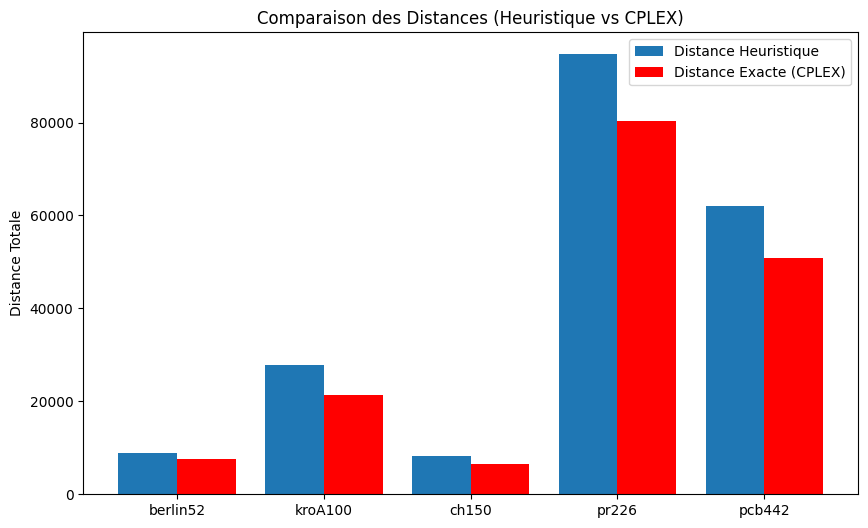

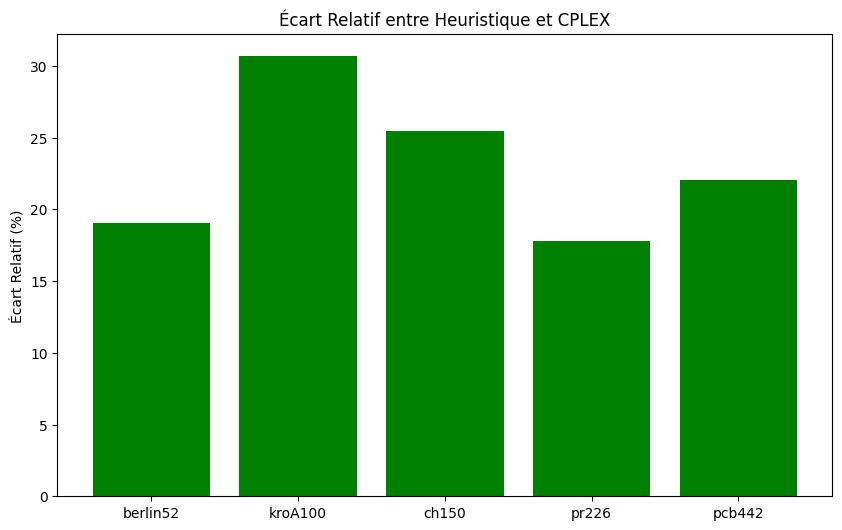

In [1]:
import matplotlib.pyplot as plt

# Données
instances = ["berlin52", "kroA100", "ch150", "pr226", "pcb442"]
heuristic_distances = [8980, 27807, 8191, 94683, 61979]
exact_distances = [7542, 21282, 6528, 80369, 50778]
relative_errors = [19.07, 30.66, 25.47, 17.81, 22.06]

# Graphique des distances
plt.figure(figsize=(10, 6))
x = range(len(instances))
plt.bar(x, heuristic_distances, width=0.4, label="Distance Heuristique", align="center")
plt.bar([i + 0.4 for i in x], exact_distances, color="red", width=0.4, label="Distance Exacte (CPLEX)", align="center")
plt.xticks([i + 0.2 for i in x], instances)
plt.ylabel("Distance Totale")
plt.title("Comparaison des Distances (Heuristique vs CPLEX)")
plt.legend()
plt.show()

# Graphique des écarts relatifs
plt.figure(figsize=(10, 6))
plt.bar(instances, relative_errors, color="green")
plt.ylabel("Écart Relatif (%)")
plt.title("Écart Relatif entre Heuristique et CPLEX")
plt.show()
